In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset/cancer/266.jpeg
/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset/cancer/071.jpeg
/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset/cancer/344.jpeg
/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset/cancer/228.jpeg
/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset/cancer/099.jpeg
/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset/cancer/130.jpeg
/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset/cancer/158.jpeg
/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset/cancer/003.jpeg
/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset/cancer/253.jpeg
/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset/cancer/014.jpeg
/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset/cancer/381.jpeg
/kaggle/input/datasets/gautiigiri/oral-data

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.model_selection import KFold

2026-04-15 17:10:17.458640: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776273017.675352      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776273017.738325      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776273018.222067      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776273018.222115      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776273018.222118      55 computation_placer.cc:177] computation placer alr

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
EPOCHS = 50   # max limit

DATASET_DIR = r"/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset"   # use raw string

filepaths = []
labels = []

class_map = {"normal": 0, "cancer": 1}

In [4]:
for class_name in os.listdir(DATASET_DIR):
    class_path = os.path.join(DATASET_DIR, class_name)
    
    if not os.path.isdir(class_path):
        continue
    
    for img in os.listdir(class_path):
        img_path = os.path.join(class_path, img)
        
        filepaths.append(img_path)
        labels.append(class_map[class_name])

filepaths = np.array(filepaths)
labels = np.array(labels)

print("Total images:", len(filepaths))
print("Sample:", filepaths[:3], labels[:3])

Total images: 950
Sample: ['/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset/cancer/266.jpeg'
 '/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset/cancer/071.jpeg'
 '/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset/cancer/344.jpeg'] [1 1 1]


In [5]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

In [6]:
def build_model():
    base_model = MobileNetV3Large(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # Freeze all layers (Phase 1)
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)
    output = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model, base_model

In [7]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

all_histories = []
all_val_acc = []
all_val_loss = []

fold_no = 1

for train_idx, val_idx in kf.split(filepaths):

    print(f"\n===== Fold {fold_no} =====")

    train_df = pd.DataFrame({
        "filename": filepaths[train_idx],
        "class": labels[train_idx]
    })

    val_df = pd.DataFrame({
        "filename": filepaths[val_idx],
        "class": labels[val_idx]
    })

    train_gen = datagen.flow_from_dataframe(
        train_df,
        x_col="filename",
        y_col="class",
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode="raw"
    )

    val_gen = datagen.flow_from_dataframe(
        val_df,
        x_col="filename",
        y_col="class",
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode="raw",
        shuffle=False
    )

    model, base_model = build_model()

    # ===== PHASE 1 =====
    print("Phase 1: Feature Extraction")

    history1 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,
        callbacks=[
            EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
        ]
    )

    # ===== PHASE 2 =====
    print("Phase 2: Fine-tuning")

    for layer in base_model.layers[-30:]:
        layer.trainable = True

    model.compile(
        optimizer=Adam(1e-5),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history2 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=[
            EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
            ModelCheckpoint(
                f"mobilenetv3_fold{fold_no}.h5",
                monitor="val_accuracy",
                save_best_only=True
            )
        ]
    )

    # ===== COMBINE HISTORIES =====
    combined_history = {}
    for key in history1.history.keys():
        combined_history[key] = history1.history[key] + history2.history[key]

    all_histories.append(combined_history)

    # ===== FINAL EVAL =====
    val_loss, val_acc = model.evaluate(val_gen, verbose=0)

    print(f"Fold {fold_no} - Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    all_val_acc.append(val_acc)
    all_val_loss.append(val_loss)

    fold_no += 1






===== Fold 1 =====
Found 760 validated image filenames.
Found 190 validated image filenames.


2026-04-15 17:10:41.615904: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Phase 1: Feature Extraction


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
40/48 ━━━━━━━━━━━━━━━━━━━━ 3s 422ms/step - accuracy: 0.3919 - loss: 0.9105

...

48/48 ━━━━━━━━━━━━━━━━━━━━ 30s 472ms/step - accuracy: 0.5082 - loss: 0.7057 - val_accuracy: 0.5105 - val_loss: 0.6902
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 408ms/step - accuracy: 0.5746 - loss: 0.6734 - val_accuracy: 0.5105 - val_loss: 0.6899
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 407ms/step - accuracy: 0.6539 - loss: 0.6218 - val_accuracy: 0.5105 - val_loss: 0.6925
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 406ms/step - accuracy: 0.7012 - loss: 0.6103 - val_accuracy: 0.5105 - val_loss: 0.6936
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 410ms/step - accuracy: 0.6395 - loss: 0.6276 - val_accuracy: 0.5105 - val_loss: 0.6979
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 412ms/step - accuracy: 0.6556 - loss: 0.6142 - val_accuracy: 0.5105 - val_loss: 0.7010
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 400ms/step - accuracy: 0.7352 - loss: 0.5685 - val_accuracy: 0.5105 - val_loss: 0.7021
Fold 1 - Val Loss: 0.6906, Val Acc: 0.5105

===== Fold 2 =====
Found 760 validated image filenames.
Found 19

48/48 ━━━━━━━━━━━━━━━━━━━━ 31s 499ms/step - accuracy: 0.5213 - loss: 0.7154 - val_accuracy: 0.5737 - val_loss: 0.6799
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 410ms/step - accuracy: 0.6203 - loss: 0.6590 - val_accuracy: 0.5737 - val_loss: 0.6779
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 406ms/step - accuracy: 0.6512 - loss: 0.6264 - val_accuracy: 0.5737 - val_loss: 0.6791
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 406ms/step - accuracy: 0.6894 - loss: 0.6078 - val_accuracy: 0.5737 - val_loss: 0.6776
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 21s 440ms/step - accuracy: 0.6629 - loss: 0.5972 - val_accuracy: 0.5737 - val_loss: 0.6772
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 410ms/step - accuracy: 0.6929 - loss: 0.6096 - val_accuracy: 0.5737 - val_loss: 0.6780
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 417ms/step - accuracy: 0.7072 - loss: 0.5827 - val_accuracy: 0.5737 - val_loss: 0.6778
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 410ms/step - accuracy: 0.7186 - loss: 0.5655 - val_accuracy: 0.573

48/48 ━━━━━━━━━━━━━━━━━━━━ 33s 515ms/step - accuracy: 0.4951 - loss: 0.7167 - val_accuracy: 0.5684 - val_loss: 0.6801
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 463ms/step - accuracy: 0.5868 - loss: 0.6704 - val_accuracy: 0.5684 - val_loss: 0.6818
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 459ms/step - accuracy: 0.5785 - loss: 0.6641 - val_accuracy: 0.5684 - val_loss: 0.6816
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 461ms/step - accuracy: 0.6187 - loss: 0.6520 - val_accuracy: 0.5684 - val_loss: 0.6818
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 42s 482ms/step - accuracy: 0.6661 - loss: 0.6182 - val_accuracy: 0.5684 - val_loss: 0.6810
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 40s 462ms/step - accuracy: 0.6864 - loss: 0.6063 - val_accuracy: 0.5684 - val_loss: 0.6829
Fold 3 - Val Loss: 0.6806, Val Acc: 0.5684

===== Fold 4 =====
Found 760 validated image filenames.
Found 190 validated image filenames.
Phase 1: Feature Extraction
Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 28s 482ms/step - accuracy: 0.5222 

48/48 ━━━━━━━━━━━━━━━━━━━━ 31s 505ms/step - accuracy: 0.5866 - loss: 0.6867 - val_accuracy: 0.4474 - val_loss: 0.6972
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 457ms/step - accuracy: 0.5823 - loss: 0.6671 - val_accuracy: 0.4474 - val_loss: 0.6986
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 460ms/step - accuracy: 0.6255 - loss: 0.6568 - val_accuracy: 0.4474 - val_loss: 0.7008
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 463ms/step - accuracy: 0.6613 - loss: 0.6361 - val_accuracy: 0.4474 - val_loss: 0.7029
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 458ms/step - accuracy: 0.6745 - loss: 0.6095 - val_accuracy: 0.4474 - val_loss: 0.7040
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 458ms/step - accuracy: 0.6733 - loss: 0.6076 - val_accuracy: 0.4474 - val_loss: 0.7051
Fold 4 - Val Loss: 0.6976, Val Acc: 0.4474

===== Fold 5 =====
Found 760 validated image filenames.
Found 190 validated image filenames.
Phase 1: Feature Extraction
Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 28s 482ms/step - accuracy: 0.5314 

48/48 ━━━━━━━━━━━━━━━━━━━━ 31s 501ms/step - accuracy: 0.5956 - loss: 0.6687 - val_accuracy: 0.5316 - val_loss: 0.6897
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 462ms/step - accuracy: 0.6058 - loss: 0.6599 - val_accuracy: 0.5316 - val_loss: 0.6892
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 448ms/step - accuracy: 0.5925 - loss: 0.6489 - val_accuracy: 0.5316 - val_loss: 0.6890
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 454ms/step - accuracy: 0.5989 - loss: 0.6442 - val_accuracy: 0.5316 - val_loss: 0.6896
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 463ms/step - accuracy: 0.6838 - loss: 0.6002 - val_accuracy: 0.5316 - val_loss: 0.6898
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 451ms/step - accuracy: 0.6713 - loss: 0.6049 - val_accuracy: 0.5316 - val_loss: 0.6906
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 454ms/step - accuracy: 0.6719 - loss: 0.5983 - val_accuracy: 0.5316 - val_loss: 0.6894
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 460ms/step - accuracy: 0.7215 - loss: 0.5612 - val_accuracy: 0.531

In [8]:

min_epochs = min(len(h["val_accuracy"]) for h in all_histories)

val_acc_matrix = []
val_loss_matrix = []

for h in all_histories:
    val_acc_matrix.append(h["val_accuracy"][:min_epochs])
    val_loss_matrix.append(h["val_loss"][:min_epochs])

val_acc_matrix = np.array(val_acc_matrix)
val_loss_matrix = np.array(val_loss_matrix)

mean_acc = np.mean(val_acc_matrix, axis=0)
mean_loss = np.mean(val_loss_matrix, axis=0)

epochs = range(1, min_epochs + 1)

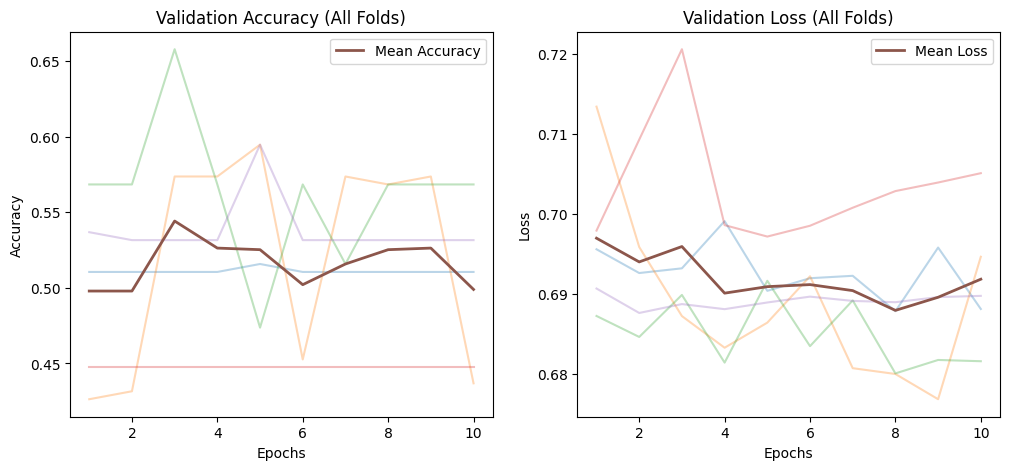


===== FINAL RESULTS =====
Mean Accuracy: 0.5263
Mean Loss: 0.6868


In [9]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)

for i in range(len(val_acc_matrix)):
    plt.plot(epochs, val_acc_matrix[i], alpha=0.3)

plt.plot(epochs, mean_acc, linewidth=2, label="Mean Accuracy")

plt.title("Validation Accuracy (All Folds)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# ---- Loss ----
plt.subplot(1,2,2)

for i in range(len(val_loss_matrix)):
    plt.plot(epochs, val_loss_matrix[i], alpha=0.3)

plt.plot(epochs, mean_loss, linewidth=2, label="Mean Loss")

plt.title("Validation Loss (All Folds)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()


# ===== FINAL METRICS =====
print("\n===== FINAL RESULTS =====")
print(f"Mean Accuracy: {np.mean(all_val_acc):.4f}")
print(f"Mean Loss: {np.mean(all_val_loss):.4f}")